<a href="https://colab.research.google.com/github/BaoTruongThai/MiniProjects/blob/main/uncertainty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part C: Implementation with Conditional Sampling

This notebook modifies the base implementation to support conditional sampling(Classifier-Free Guidance), as required by the assignment
.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import os

In [45]:
# 1. Configuration / Hyperparameters

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 128
EPOCHS = 20       # Increased epochs for better results
LR = 1e-3
TIMESTEPS = 300
IMG_DIM = 28
IMG_CHANNELS = 1
N_CLASSES = 10    # MNIST has 10 classes (digits 0-9)
NULL_CLASS = 10   # A special "null" class for unconditional generation

In [17]:
# Create a directory to save results
os.makedirs("results", exist_ok=True)


2. Diffusion Model Helper Functions (The "Forward Process")
(This section is unchanged from the base implementation)

In [46]:
def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps, device=DEVICE)

In [47]:
def cosine_beta_schedule(timesteps, s=0.008):
    """
    Creates a cosine variance schedule as described in
    "Improved Denoising Diffusion Probabilistic Models" (Nichol & Dhariwal, 2021)
    """
    steps = timesteps + 1
    t = torch.linspace(0, timesteps, steps, device=DEVICE)
    alphas_cumprod = torch.cos(((t / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

In [48]:
# betas = linear_beta_schedule(timesteps=TIMESTEPS) # Original
betas = cosine_beta_schedule(timesteps=TIMESTEPS)  # MODIFICATION: Use Cosine Schedule
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

In [49]:
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

In [50]:
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

In [51]:
def extract(a, t, x_shape):
    batch_size = t.shape[0]
    out = a.gather(-1, t)
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

In [52]:
def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)

    sqrt_alphas_cumprod_t = extract(sqrt_alphas_cumprod, t, x_start.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(
        sqrt_one_minus_alphas_cumprod, t, x_start.shape
    )

    return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise

3. The Neural Network (The "Reverse Process")

### MODIFICATION ###
The U-Net is modified to accept class labels 'y' as an input. These labels are embedded and added to the time embedding.

In [53]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = torch.log(torch.tensor(10000.0, device=device)) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

In [54]:
class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)

    def forward(self, x, t_emb):
        # Time embedding is now pre-mixed with label embedding
        t = self.relu(self.time_mlp(t_emb))
        t = t.view(t.shape[0], t.shape[1], 1, 1)

        x = self.conv1(x)
        x = self.relu(x)

        x = x + t

        x = self.conv2(x)
        x = self.relu(x)
        return x

In [55]:
class SimpleUnet(nn.Module):
    def __init__(self):
        super().__init__()

        time_emb_dim = 32

        # --- Encoder (Downsampling) ---
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )

        ### MODIFICATION ###
        # Add an embedding layer for the class labels
        # We add 1 to N_CLASSES for the "null" class
        self.label_emb = nn.Embedding(N_CLASSES + 1, time_emb_dim)

        self.down1 = Block(IMG_CHANNELS, 32, time_emb_dim)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = Block(32, 64, time_emb_dim)
        self.pool2 = nn.MaxPool2d(2)

        self.bot1 = Block(64, 128, time_emb_dim)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = Block(128, 64, time_emb_dim)
        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = Block(64, 32, time_emb_dim)

        self.out_conv = nn.Conv2d(32, IMG_CHANNELS, kernel_size=1)

    def forward(self, x, t, y):
        # Get time embeddings
        t_emb = self.time_mlp(t)

        ### MODIFICATION ###
        # Get label embeddings
        y_emb = self.label_emb(y)

        # Combine time and label embeddings
        combined_emb = t_emb + y_emb

        # --- Encoder ---
        x1 = self.down1(x, combined_emb)
        x_pool1 = self.pool1(x1)
        x2 = self.down2(x_pool1, combined_emb)
        x_pool2 = self.pool2(x2)

        x_bot = self.bot1(x_pool2, combined_emb)

        # --- Decoder with Skip Connections ---
        x_up1 = self.up1(x_bot)
        x_skip1 = torch.cat([x_up1, x2], dim=1)
        x_dec1 = self.dec1(x_skip1, combined_emb)

        x_up2 = self.up2(x_dec1)
        x_skip2 = torch.cat([x_up2, x1], dim=1)
        x_dec2 = self.dec2(x_skip2, combined_emb)

        return self.out_conv(x_dec2)

4. Training


In [56]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 2) - 1)
])
dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [57]:
model = SimpleUnet().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

In [58]:
print(f"--- Starting Training on {DEVICE} ---")
print(f"Epochs: {EPOCHS}, Batch Size: {BATCH_SIZE}, Timesteps: {TIMESTEPS}")

--- Starting Training on cpu ---
Epochs: 20, Batch Size: 128, Timesteps: 300


In [59]:
for epoch in range(EPOCHS):
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    ### MODIFICATION: We now get 'labels' from the dataloader ###
    for batch_idx, (images, labels) in enumerate(progress_bar):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        t = torch.randint(0, TIMESTEPS, (images.shape[0],), device=DEVICE).long()
        noise = torch.randn_like(images)
        x_t = q_sample(x_start=images, t=t, noise=noise)

        ### MODIFICATION: Classifier-Free Guidance Training ###
        #
        # With a 10% probability, we "drop" the class label and
        # replace it with the "null" class. This forces the model
        # to learn both conditional and unconditional generation.
        #
        prob = torch.rand(labels.shape[0], device=DEVICE)
        mask = prob < 0.1
        labels[mask] = NULL_CLASS # Set 10% of labels to "null"

        ### MODIFICATION: Pass labels to the model ###
        predicted_noise = model(x_t, t, labels)

        loss = criterion(noise, predicted_noise)

        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            progress_bar.set_postfix(loss=loss.item())

Epoch 1/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 3/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 4/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 5/20:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 16/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 17/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 18/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 19/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 20/20:   0%|          | 0/469 [00:00<?, ?it/s]

In [60]:
print("--- Training Complete ---")

--- Training Complete ---


In [61]:
# Save the trained model
torch.save(model.state_dict(), f"mnist_diffusion_{EPOCHS}epochs_conditional.pth")
print(f"Model saved to mnist_diffusion_{EPOCHS}epochs_conditional.pth")

Model saved to mnist_diffusion_20epochs_conditional.pth


=============================================================================
5. Sampling (Now with Classifier-Free Guidance)
=============================================================================

## MODIFICATION ###
The sampling loop is updated to perform guided sampling.

In [62]:
@torch.no_grad()
def p_sample_loop(model, shape, y, guidance_scale=0):
    """
    The full reverse sampling loop with Classifier-Free Guidance.

    y: The class to generate (e.g., torch.tensor([4]))
    guidance_scale: How strongly to "push" the generation towards y.
                    0 = unconditional generation.
    """
    model.eval()

    batch_size = shape[0]
    img = torch.randn(shape, device=DEVICE)

    # Create the "null" class tensor for unconditional prediction
    y_uncond = torch.full((batch_size,), NULL_CLASS, device=DEVICE, dtype=torch.long)
    y_cond = y.long() # The desired class

    for t in tqdm(reversed(range(0, TIMESTEPS)), desc="Sampling"):
        t_tensor = torch.full((batch_size,), t, device=DEVICE, dtype=torch.long)

        ### MODIFICATION: Perform two predictions ###

        # 1. Predict noise for the *conditional* case (with our label)
        pred_noise_cond = model(img, t_tensor, y_cond)

        # 2. Predict noise for the *unconditional* case (with null label)
        pred_noise_uncond = model(img, t_tensor, y_uncond)

        ### MODIFICATION: Combine predictions (CFG) ###
        #
        # predicted_noise = unconditional_pred + guidance * (conditional - unconditional)
        # This is the "guidance" step.
        predicted_noise = pred_noise_uncond + guidance_scale * (
            pred_noise_cond - pred_noise_uncond
        )

        # --- Denoise one step (same as before) ---
        alpha_t = extract(alphas, t_tensor, img.shape)
        sqrt_recip_alpha_t = extract(sqrt_recip_alphas, t_tensor, img.shape)
        betas_t = extract(betas, t_tensor, img.shape)
        sqrt_one_minus_alphas_cumprod_t = extract(
            sqrt_one_minus_alphas_cumprod, t_tensor, img.shape
        )

        model_mean = sqrt_recip_alpha_t * (
            img - betas_t * predicted_noise / sqrt_one_minus_alphas_cumprod_t
        )

        if t == 0:
            img = model_mean
        else:
            posterior_variance_t = extract(posterior_variance, t_tensor, img.shape)
            noise = torch.randn_like(img)
            img = model_mean + torch.sqrt(posterior_variance_t) * noise

    model.train()
    img = (img + 1) * 0.5
    img = torch.clamp(img, 0, 1)
    return img

In [63]:
# --- Helper function to plot generated images ---
def show_images(images, title=""):
    images = images.cpu()
    grid = make_grid(images, nrow=4)
    plt.figure(figsize=(5, 5))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(title)
    plt.axis("off")
    plt.show()

In [64]:

# 6. Run Experiments (Part C, Step 2)
# Now you can run the experiments required by the assignment.
#
print("--- Running Experiments ---")

--- Running Experiments ---


In [65]:
# --- Experiment 1: Effect of Guidance (e.g., on digit '4') ---
n_samples = 4
digit_to_generate = 4
y = torch.full((n_samples,), digit_to_generate, device=DEVICE)

Sampling: 0it [00:00, ?it/s]

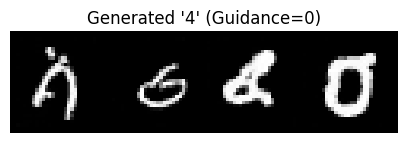

In [66]:
# 1. Guidance = 0 (Unconditional)
samples_g0 = p_sample_loop(model, (n_samples, 1, 28, 28), y, guidance_scale=0)
show_images(samples_g0, title=f"Generated '{digit_to_generate}' (Guidance=0)")

Sampling: 0it [00:00, ?it/s]

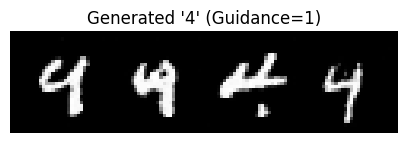

In [67]:
# 2. Guidance = 1
samples_g1 = p_sample_loop(model, (n_samples, 1, 28, 28), y, guidance_scale=1)
show_images(samples_g1, title=f"Generated '{digit_to_generate}' (Guidance=1)")

Sampling: 0it [00:00, ?it/s]

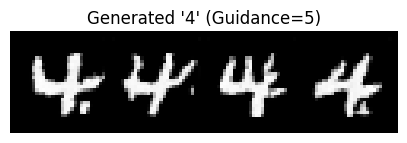

In [68]:
# 3. Guidance = 5
samples_g5 = p_sample_loop(model, (n_samples, 1, 28, 28), y, guidance_scale=5)
show_images(samples_g5, title=f"Generated '{digit_to_generate}' (Guidance=5)")
save_image(make_grid(samples_g5, nrow=4), f"results/mnist_g5_digit_{digit_to_generate}.png")

In [69]:
# --- Experiment 2: Generate another digit (e.g., '0') ---
digit_to_generate = 0
y = torch.full((n_samples,), digit_to_generate, device=DEVICE)

Sampling: 0it [00:00, ?it/s]

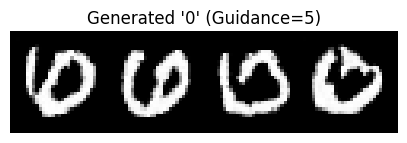

In [70]:
samples_g5_d0 = p_sample_loop(model, (n_samples, 1, 28, 28), y, guidance_scale=5)
show_images(samples_g5_d0, title=f"Generated '{digit_to_generate}' (Guidance=5)")
save_image(make_grid(samples_g5_d0, nrow=4), f"results/mnist_g5_digit_{digit_to_generate}.png")

--- You can now add more experiments ---
e.g., train a model with a larger/smaller U-Net,
or change the number of epochs and re-run this sampling.